In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from dotenv import load_dotenv

load_dotenv()

from sqlalchemy import create_engine
import os

def connect_to_db():
    engine = create_engine(
        f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@"
        f"{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
    )
    return engine

engine = connect_to_db()

conn = engine.connect()

In [3]:
df = pd.read_sql("SELECT * FROM public.gold_model_dataset", engine)

df.head()

,user_id,is_mobile,is_package,channel,cnt,trip_type,is_family_trip,is_multi_room,total_guests,stay_duration,...,avg_session_intensity,avg_stay_duration,avg_advance_booking_days,mobile_usage_rate,destination_booking_rate,destination_popularity,cluster_booking_rate,cluster_popularity,hotel_cluster,is_booking
0,14,0,0,9,1,solo,0,0,1,2,...,1.0,2.0,54.0,0.0,0.0697,3544,0.0341,264,88,0
1,38,0,0,2,1,group,0,0,2,4,...,1.0,4.0,123.0,0.0,0.1277,47,0.1001,1129,33,0
2,40,0,0,0,1,solo,0,0,1,1,...,1.0,1.0,1.0,0.0,0.1000,100,0.0655,885,76,0
3,156,0,0,5,1,family,1,0,4,1,...,1.0,1.0,14.0,0.0,0.1215,214,0.1317,896,13,0
4,156,0,0,5,1,family,1,0,4,1,...,1.0,1.0,14.0,0.0,0.1215,214,0.1143,1260,16,0


In [4]:
num_cols = [
    "stay_duration",
    "advance_booking_days",
    "orig_destination_distance",
    "cnt",
    "total_guests"
]

cat_cols = [
    "is_mobile",
    "is_package",
    "channel",
    "trip_type",
    "srch_destination_type_id"
]

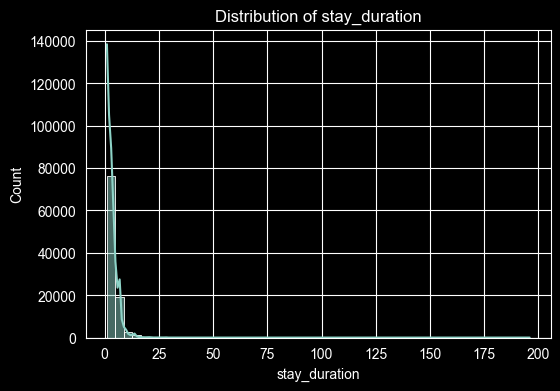

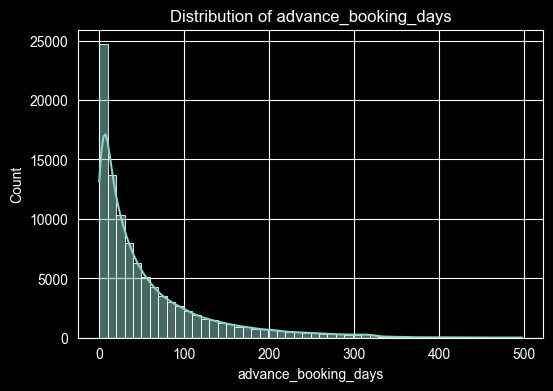

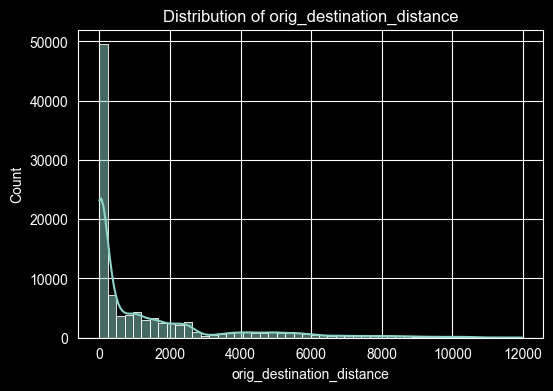

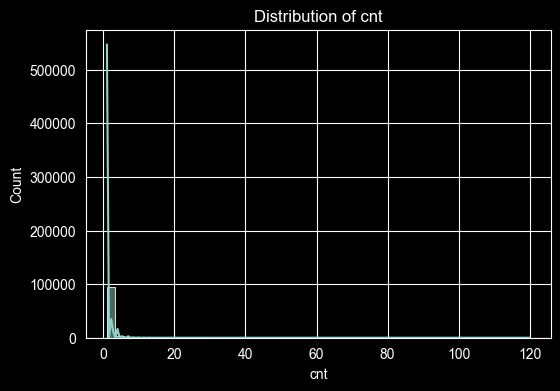

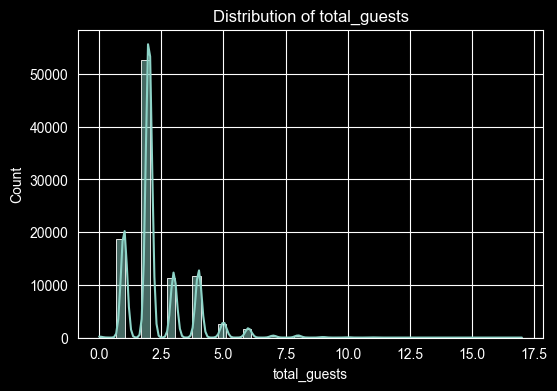

In [5]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

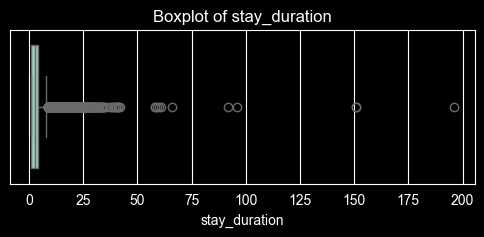

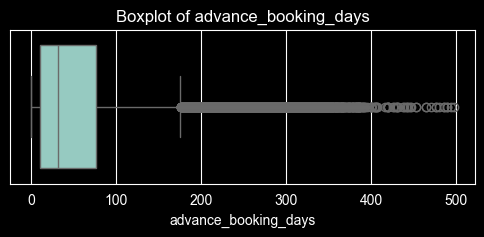

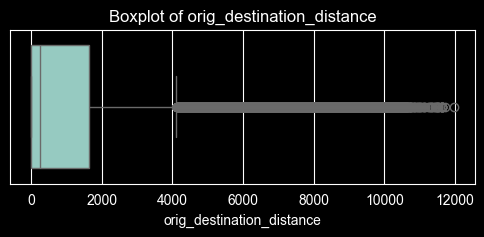

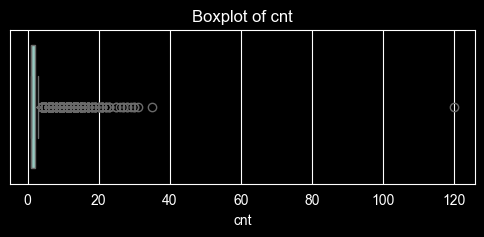

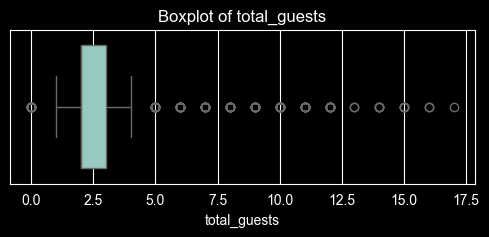

In [6]:
for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [7]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
stay_duration,99471.0,3.384856,2.998416,1.0,1.0,3.0000,4.0000,196.0000
advance_booking_days,99471.0,55.185320,65.680203,0.0,10.0,31.0000,76.0000,497.0000
orig_destination_distance,99471.0,1252.375221,2015.749340,-1.0,-1.0,244.9252,1644.7216,11965.3761
cnt,99471.0,1.489419,1.282138,1.0,1.0,1.0000,2.0000,120.0000
total_guests,99471.0,2.356677,1.229175,0.0,2.0,2.0000,3.0000,17.0000


In [8]:
for col in num_cols:
    p1, p50, p99 = np.percentile(df[col], [1, 50, 99])
    print(f"{col} → P1: {p1:.2f} | Median: {p50:.2f} | P99: {p99:.2f}")

stay_duration → P1: 1.00 | Median: 3.00 | P99: 14.00
advance_booking_days → P1: 0.00 | Median: 31.00 | P99: 300.00
orig_destination_distance → P1: -1.00 | Median: 244.93 | P99: 8909.98
cnt → P1: 1.00 | Median: 1.00 | P99: 7.00
total_guests → P1: 1.00 | Median: 2.00 | P99: 6.00


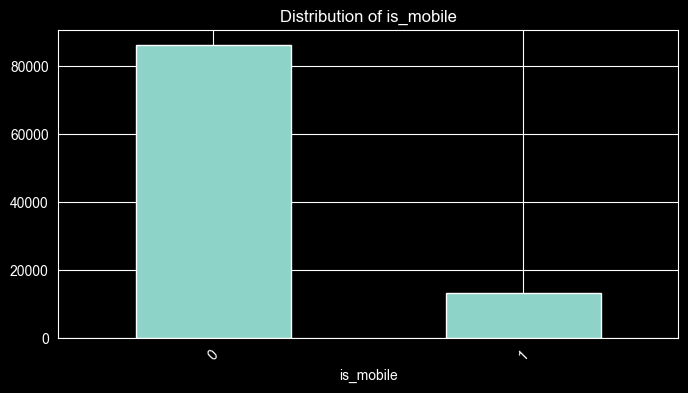

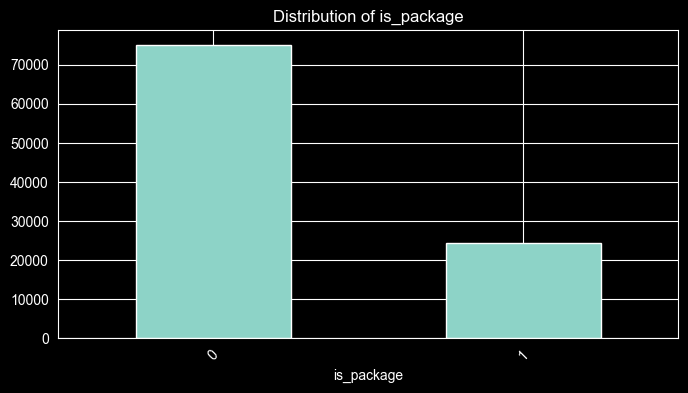

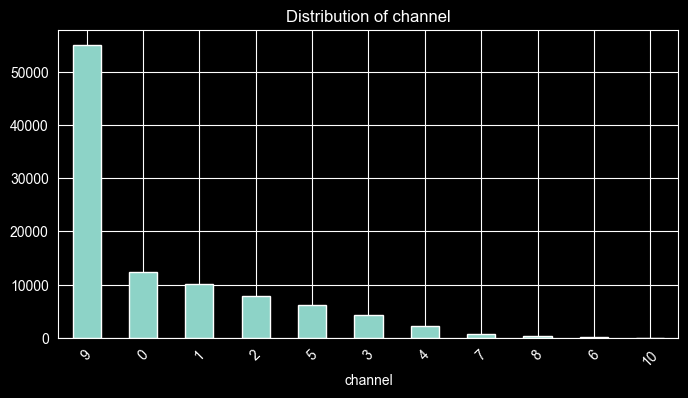

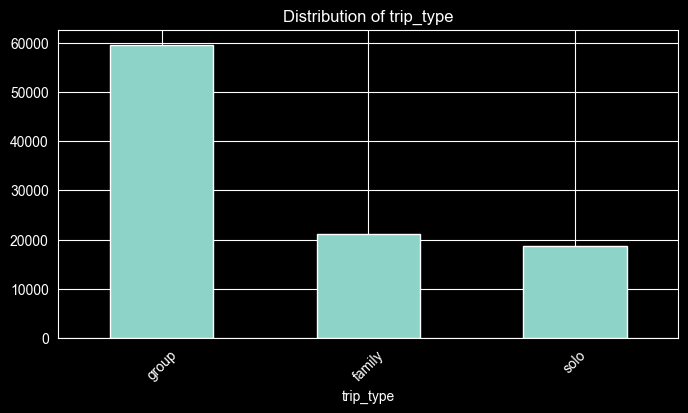

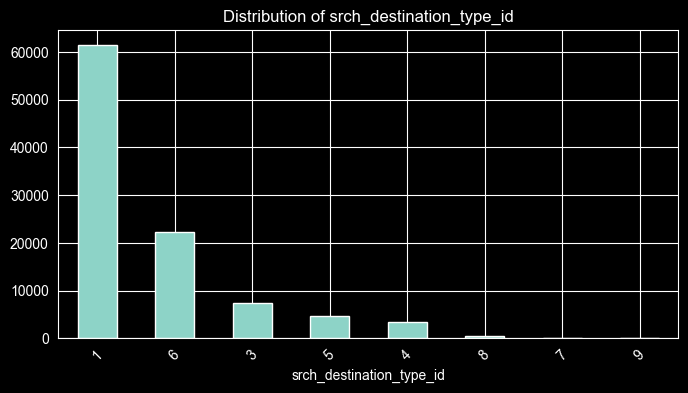

In [9]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [10]:
for col in cat_cols:
    print(f"{col}: {df[col].nunique()}")

is_mobile: 2
is_package: 2
channel: 11
trip_type: 3
srch_destination_type_id: 8


In [11]:
(df["orig_destination_distance"] == -1).sum()

np.int64(35884)

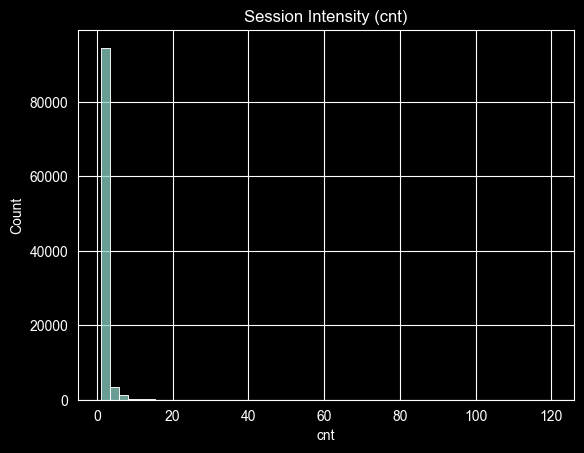

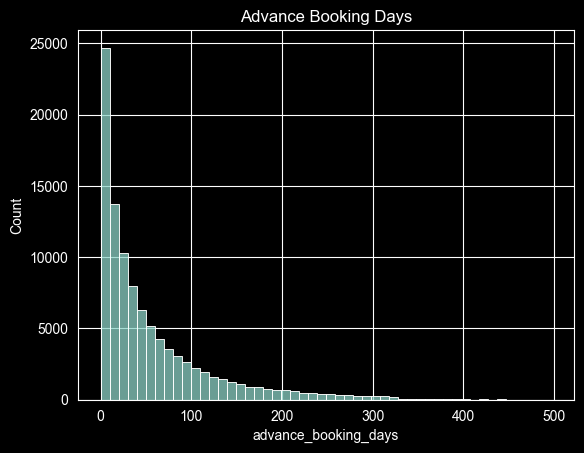

In [12]:
sns.histplot(df["cnt"], bins=50)
plt.title("Session Intensity (cnt)")
plt.show()

sns.histplot(df["advance_booking_days"], bins=50)
plt.title("Advance Booking Days")
plt.show()

In [13]:
conn.close()